# # Data Harvesting
# This notebook handles data loading, preprocessing, model training, and activity monitoring 
# for the Spiking Heidelberg Digits (SHD) dataset.

In [1]:
import os
import json
import torch
import torch.nn as nn
import numpy as np
import random
import h5py
from manifolduntanglinganalysis.training import Trainer
import models.sffnn_batched as sffnn_batched
import manifolduntanglinganalysis.preprocessing.datatransforms as datatransforms
import manifolduntanglinganalysis.preprocessing.dataloader as dataloader
from manifolduntanglinganalysis.ActivityMonitor import ActivityMonitor
from manifolduntanglinganalysis.preprocessing.metadata_extractor import SHDMetadataExtractor

## 1. Setup and Reproducibility

In [2]:
import os
import json
import random
import torch
import torch.nn as nn
import numpy as np

import manifolduntanglinganalysis.preprocessing.datatransforms as datatransforms
import manifolduntanglinganalysis.preprocessing.dataloader as dataloader
from manifolduntanglinganalysis.training import Trainer
import models.sffnn_batched as sffnn_batched
from manifolduntanglinganalysis.ActivityMonitor import ActivityMonitor
from manifolduntanglinganalysis.preprocessing.metadata_extractor import SHDMetadataExtractor

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)
torch.cuda.manual_seed_all(42)

# Project roots and paths
project_root = os.path.abspath(os.path.join(os.getcwd(), "..","..")) # Adjust relative path if needed
data_path = os.path.join(project_root, "data", "input")

## 2. Data Loading and Preprocessing

In [3]:
# Define preprocessing transformations
transform = datatransforms.get_preprocessing(
    n_time_bins=80,
    target_neurons=350,
    original_neurons=700,
    fixed_duration=958007.0
)

# Load dataloaders
train_dataloader = dataloader.load_filtered_shd_dataloader(
    label_range=range(0, 10),
    data_path=data_path,
    transform=transform, 
    train=True, 
    batch_size=64
)

test_dataloader = dataloader.load_filtered_shd_dataloader(
    label_range=range(0, 10), 
    data_path=data_path,
    transform=transform, 
    train=False,
    batch_size=64
)

## 3. Model Definition and Training Setup

In [4]:
# Initialize the model
net = sffnn_batched.Net(
    num_inputs=350,      
    num_hidden1=128,     
    num_hidden2=64,      
    num_outputs=10, 
    num_steps=80,      
    beta=0.9
).to(device)

# Training configurations
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(net.parameters(), lr=5e-4)
num_epochs = 10

trainer = Trainer(net, optimizer, loss_fn, device, project_root=project_root)

# Activity monitoring configuration
MONITORING_CONFIG = {
    'num_samples': 1000,
    'layer_names': ['lif0', 'lif1', 'lif2', 'lif3'],
    'save_dir': os.path.join(project_root, "data", "activity_logs")
}
os.makedirs(MONITORING_CONFIG['save_dir'], exist_ok=True)

## 4. Training and Activity Monitoring

In [5]:
for epoch in range(1, num_epochs + 1):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch}/{num_epochs}")
    print(f"{'='*80}")
    
    train_loss, train_acc = trainer.train_epoch(train_dataloader)
    val_metrics = trainer.evaluate(test_dataloader)
    
    print(f"Train - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    print(f"Val   - Loss: {val_metrics['loss']:.4f}, Accuracy: {val_metrics['accuracy']:.4f}, "
          f"F1: {val_metrics['f1']:.4f}, AUC-ROC: {val_metrics['auc_roc']:.4f}")
    
    # Activity Monitoring
    print(f"\n🧪 Activity Monitoring after Epoch {epoch}:")
    metadata_extractor = SHDMetadataExtractor()
    input_transform = lambda x: x.squeeze(2) if x.ndim == 4 else x
    
    activity_monitor = ActivityMonitor(
        net,
        metadata_extractor=metadata_extractor,
        input_transform=input_transform
    )
    
    activity_monitor.enable_monitoring(lif_layer_names=MONITORING_CONFIG['layer_names'])
    
    activity_monitor.monitor_and_save_samples(
        dataloader=test_dataloader,
        num_samples=MONITORING_CONFIG['num_samples'],
        layer_names=MONITORING_CONFIG['layer_names'],
        save_dir=MONITORING_CONFIG['save_dir'],
        epoch=epoch,
        device=device,
        verbose=True
    )
    
    activity_monitor.disable_monitoring()


Epoch 1/10
Train - Loss: 2.4222, Accuracy: 0.2251
Val   - Loss: 2.0873, Accuracy: 0.2236, F1: 0.1467, AUC-ROC: 0.6929

🧪 Activity Monitoring after Epoch 1:
Skipping  because it has children
Registered hook for fc0
✅ Registered hook for LIF-Layer: lif0
Registered hook for fc1
✅ Registered hook for LIF-Layer: lif1
Registered hook for fc2
✅ Registered hook for LIF-Layer: lif2
Registered hook for fc3
✅ Registered hook for LIF-Layer: lif3
📊 Überwache 1000 Samples (16 Batches)...
   ✅ 64/1000 Samples gesammelt
   ✅ 128/1000 Samples gesammelt
   ✅ 192/1000 Samples gesammelt
   ✅ 256/1000 Samples gesammelt
   ✅ 320/1000 Samples gesammelt
   ✅ 384/1000 Samples gesammelt
   ✅ 448/1000 Samples gesammelt
   ✅ 512/1000 Samples gesammelt
   ✅ 576/1000 Samples gesammelt
   ✅ 640/1000 Samples gesammelt
   ✅ 704/1000 Samples gesammelt
   ✅ 768/1000 Samples gesammelt
   ✅ 832/1000 Samples gesammelt
   ✅ 896/1000 Samples gesammelt
   ✅ 960/1000 Samples gesammelt
   ✅ 1000/1000 Samples gesammelt
✅ Monito

## 5. Save Training Performance and Model

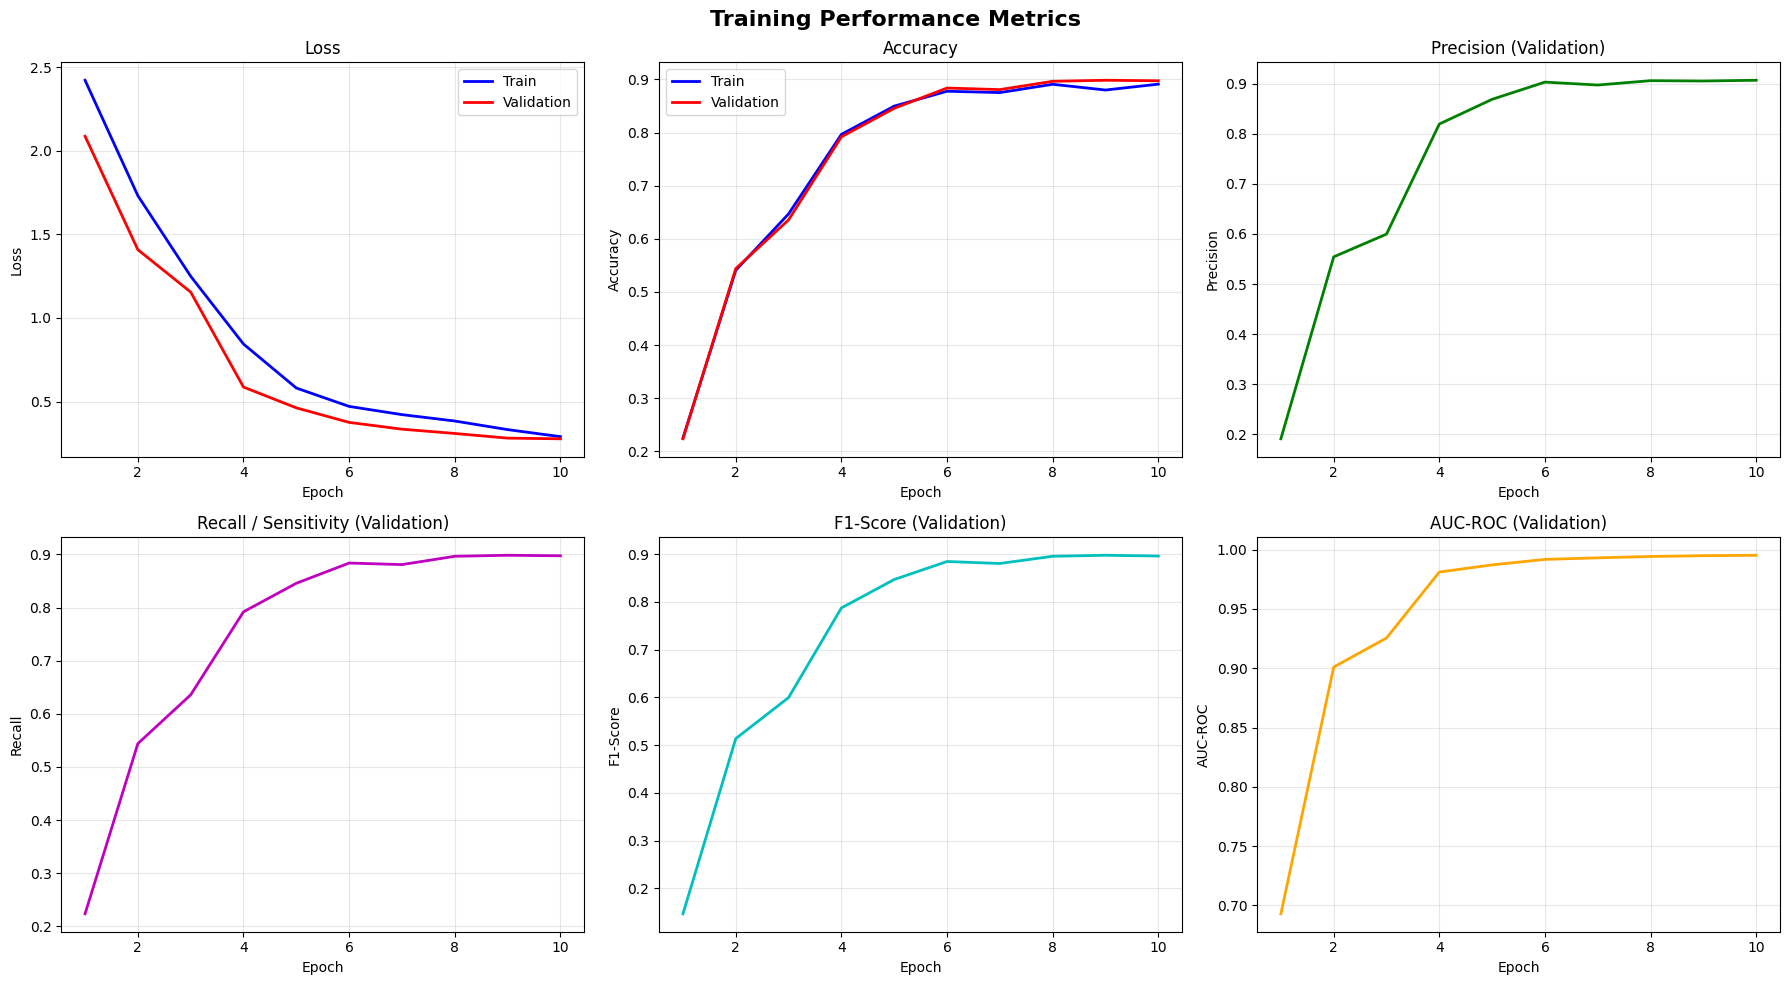


✅ Performance plots saved: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/plots/PerformanceMetriken.png
✅ Performance metrics saved: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/data/results/performance_metrics.json
✅ Model weights saved: /home/karl-/git/SNN-Training-Evolution-Manifold-Untangling-Analysis/models/model_export/model_weights.pth


In [6]:
# Save performance plots
plot_path = trainer.save_plots()
print(f"\n✅ Performance plots saved: {plot_path}")

# Structure and save performance metrics
results_dir = os.path.join(project_root, "data", "results")
os.makedirs(results_dir, exist_ok=True)

performance_metrics = {
    'epochs': list(range(1, len(trainer.history['train_loss']) + 1)),
    'train_loss': [float(x) for x in trainer.history['train_loss']],
    'train_accuracy': [float(x) for x in trainer.history['train_accuracy']],
    'val_loss': [float(x) for x in trainer.history['val_loss']],
    'val_accuracy': [float(x) for x in trainer.history['val_accuracy']],
    'val_precision': [float(x) for x in trainer.history['val_precision']],
    'val_recall': [float(x) for x in trainer.history['val_recall']],
    'val_f1': [float(x) for x in trainer.history['val_f1']],
    'val_auc_roc': [float(x) for x in trainer.history['val_auc_roc']]
}

performance_json_path = os.path.join(results_dir, "performance_metrics.json")
with open(performance_json_path, 'w') as f:
    json.dump(performance_metrics, f, indent=2)
print(f"✅ Performance metrics saved: {performance_json_path}")

# Save the model
model_export_path = os.path.join(project_root, "models", "model_export")
os.makedirs(model_export_path, exist_ok=True)
torch.save(net.state_dict(), os.path.join(model_export_path, "model_weights.pth"))
print(f"✅ Model weights saved: {os.path.join(model_export_path, 'model_weights.pth')}")